# 10 - Research Summary

Produces the research-ready methodology, tables, figures, limitations, reproducibility
manifest, and conclusions for the capstone, drawing on the saved artifacts from every prior
notebook. This is also the intended source for the Research Results page in the demo web
app (Section 9, docs/BLUEPRINT.md).

Reads only already-saved results -- no classifier is re-run here.

### Load everything this summary is built from -- again, nothing is re-run

**Purpose:** Load the frozen split (for dataset-level statistics), each method's saved test
metrics report, and the comparison tables notebook 09 already computed and saved.

**Why this step is necessary:** This notebook's purpose is to *assemble a final report*
from work already done -- it never trains a model, calls an LLM, or recomputes a metric.
Reading everything back from disk (rather than trusting in-memory variables left over from
other notebooks, which wouldn't exist in a fresh run anyway) is what makes this notebook
independently re-runnable at any time to regenerate the summary, as long as the earlier
notebooks' saved artifacts still exist.

**Inputs:** `data/splits/*.csv`, `artifacts/reports/{bert,llm,llm_rag}_test_metrics.json`,
and the three comparison CSVs notebook 09 saved
(`model_comparison_summary.csv`, `model_comparison_per_class.csv`, `error_analysis.csv`).

**Output:** `train_df`/`val_df`/`test_df`/`manifest`, `reports` (per-method metrics), and
`summary`/`per_class_df`/`error_df` (notebook 09's saved comparison tables).

**How to interpret the result:** No output is printed; success just means every prior
notebook's saved artifact was found and loaded correctly.

In [1]:
import sys
import platform
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from newstart_ai.config import load_settings
from newstart_ai.data import load_split
from newstart_ai.evaluation import load_metrics_report
from newstart_ai.models.bert import latest_ready_artifact_id, load_artifact_metadata

settings = load_settings()
train_df, val_df, test_df, manifest = load_split(settings)
methods = ["bert", "llm", "llm_rag"]
reports = {m: load_metrics_report(m, "test", settings) for m in methods}

# Reload notebook 09's saved comparison tables rather than recomputing them -- this keeps
# the research summary strictly downstream of, and consistent with, the error-analysis
# notebook's own numbers.
reports_dir = settings.resolve_path("artifacts/reports")
summary = pd.read_csv(reports_dir / "model_comparison_summary.csv")
per_class_df = pd.read_csv(reports_dir / "model_comparison_per_class.csv")
error_df = pd.read_csv(reports_dir / "error_analysis.csv")

## 1. Methodology

**Research question:** How accurately and practically can a fine-tuned BERT classifier, an
LLM classifier, and an LLM+RAG classifier route the same government-document text to the
correct agency?

**Dataset:** `data/processed/final_dataset.csv`, built by the Phase 0 crawler pipeline
(`notebooks/00_data_acquisition/`) from public USCIS, California DMV, SSA, and IRS documents.
754 labeled documents across exactly four classes.

**Split:** one frozen, reproducible stratified 64/16/20 train/validation/test split
(seed 42), created once in `03_reproducible_splitting.ipynb` and never touched again except
by each method's single frozen test evaluation.

### Restate the dataset and split at a glance

**Purpose:** Print the total document count, the size of each split, and the full dataset's
class distribution -- the basic facts a reader needs before looking at any results.

**Why this step is necessary:** A research summary should be able to stand on its own; a
reader shouldn't have to open notebooks 01-03 just to know how big the dataset is or how
imbalanced the classes are. This cell restates those facts concisely as the summary's
opening context.

**Inputs:** `train_df`, `val_df`, `test_df` (concatenated back together just for this
full-dataset count) and `settings` (for the label column name).

**Output:** Printed text.

**How to interpret the result:** These numbers should exactly match notebook 03's split
(482/121/151, 754 total) and notebook 01/02's class counts (DMV 277, USCIS 256, SSA 198,
IRS 23) -- this cell doesn't compute anything new, it just re-presents facts already
established earlier in the pipeline.

In [2]:
label_col = settings.base.dataset.label_column
print(f"Total documents: {len(train_df) + len(val_df) + len(test_df)}")
print(f"Train: {len(train_df)}   Validation: {len(val_df)}   Test: {len(test_df)}")
print()
print("Class distribution (full dataset):")
print(pd.concat([train_df, val_df, test_df])[label_col].value_counts())

Total documents: 754
Train: 482   Validation: 121   Test: 151

Class distribution (full dataset):
agency
DMV      277
USCIS    256
SSA      198
IRS       23
Name: count, dtype: int64


## 2. Model comparison (frozen test set)

### Display the final model comparison table

**Purpose:** Show notebook 09's saved summary table -- the same head-to-head numbers
computed there, simply redisplayed here as the research summary's central table.

**Inputs:** `summary` (loaded from disk above).

**Output:** The comparison DataFrame, rendered as this notebook's cell output.

**How to interpret the result:** This is the single table most likely to be read on its own
-- it should be interpreted exactly as described in notebook 09 (macro F1 as the primary
metric, BERT's cost fields absent because it has no per-call API cost).

In [3]:
summary

,method,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mean_latency_ms,total_estimated_cost,cost_per_document
0,bert,0.993377,0.958333,0.993750,0.974108,0.993637,16.419130,NaN,NaN
1,llm,0.986755,0.953526,0.989205,0.969387,0.987016,1507.914583,0.109898,0.000728
2,llm_rag,0.986755,0.953526,0.989205,0.969387,0.987016,1555.752865,0.123073,0.000815


### Render and save the headline comparison figure

**Purpose:** Draw two side-by-side bar charts -- macro F1 per method, and mean latency per
method (log scale, since latency spans milliseconds to seconds) -- and save the figure as a
PNG for reuse outside the notebook (e.g. the future Research Results page).

**Why this step is necessary:** A table of numbers and a chart communicate differently; the
chart makes both findings visually immediate: the three methods' accuracy is very close
together, while their latency differs by roughly two orders of magnitude. Saving it as a
file (not just displaying it inline) is what lets this exact figure be reused later without
regenerating it.

**Inputs:** `summary` (macro F1 and latency columns).

**Output:** A two-panel Matplotlib figure, displayed inline and saved to
`artifacts/reports/model_comparison_figure.png`.

**How to interpret the result:** The left panel's bars should look close in height (all
three methods score above 0.96 macro F1); the right panel's bars, on a log scale, should
show BERT dramatically shorter than the two LLM-based methods -- reflecting local GPU
inference versus a network API call.

Saved figure to D:\USD\Projects\a590\newstart-ai\newstart_ai_benchmark\artifacts\reports\model_comparison_figure.png


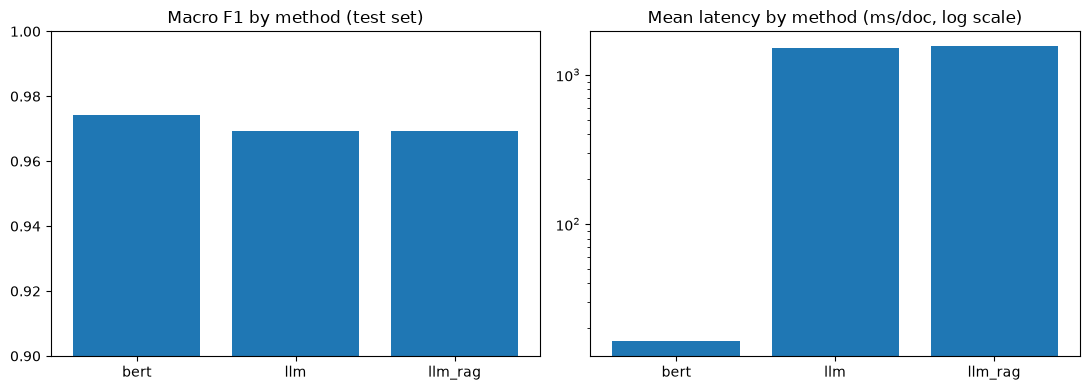

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(summary["method"], summary["macro_f1"])
axes[0].set_title("Macro F1 by method (test set)")
axes[0].set_ylim(0.9, 1.0)

# Log scale is necessary here because BERT's latency (milliseconds) and the LLM-based
# methods' latency (seconds) differ by roughly two orders of magnitude -- a linear scale
# would make BERT's bar invisible.
axes[1].bar(summary["method"], summary["mean_latency_ms"])
axes[1].set_title("Mean latency by method (ms/doc, log scale)")
axes[1].set_yscale("log")

fig.tight_layout()
fig_path = reports_dir / "model_comparison_figure.png"
fig.savefig(fig_path, dpi=150)
print(f"Saved figure to {fig_path}")

## 3. Per-class results (all four agencies)

### Display the per-class results table

**Purpose:** Show notebook 09's per-class F1 comparison (one row per agency, one column per
method) as part of the final summary.

**Inputs:** `per_class_df` (loaded from disk above).

**Output:** The pivoted per-class F1 table.

**How to interpret the result:** As throughout this project, read IRS's row with its known
small-sample caveat in mind (only ~5 test documents) rather than treating it as precisely
comparable to the other three agencies' much larger test-set support.

In [5]:
per_class_df.pivot(index="label", columns="method", values="f1")

method,bert,llm,llm_rag
label,,,
DMV,1.000000,0.990826,0.990826
IRS,0.909091,0.909091,0.909091
SSA,0.987342,0.987342,0.987342
USCIS,1.000000,0.990291,0.990291


## 4. Practical recommendation (criteria-based, not a single universal winner)

- **Best accuracy / macro F1:** BERT (0.993 / 0.974) -- one fewer error than LLM/LLM+RAG on
  the 151-document test set.
- **Fastest and cheapest to run:** BERT -- 16ms/doc, no per-call API cost, once trained.
- **Lowest per-document API cost among the two LLM-based methods:** plain LLM
  (~$0.0007/doc) -- LLM+RAG costs slightly more (~$0.0008/doc) for identical predictions on
  this test set.
- **If a trained BERT artifact isn't available or the task is expected to drift** (new
  agencies, evolving document formats) **without retraining capacity**, the LLM approach is
  the more flexible choice at a modest per-document cost.
- **RAG is not recommended for this specific task as implemented:** it added cost and
  latency without changing a single test-set prediction relative to the plain LLM (see
  `09_model_comparison_and_error_analysis.ipynb`).

## 5. Reproducibility manifest

### Assemble the reproducibility manifest

**Purpose:** Collect, into one dictionary, every piece of information someone would need to
understand exactly how this project's results were produced: the dataset's content
fingerprint, the split sizes and seed, BERT's exact base model and chosen long-document
strategy, the LLM provider/model/prompt version, the RAG embedding model and retrieval
settings, the resolved demo routing method, and basic environment information.

**Why this step is necessary:** Reproducibility is a core commitment of this project's
design -- a result is only meaningful if someone else (or a future run) can verify what
configuration actually produced it. This manifest is the single, complete record of that
configuration, gathered from the artifacts and settings that already exist rather than
re-derived or guessed.

**Inputs:** `manifest` (the split manifest from notebook 03), the BERT artifact's saved
metadata, and the current `settings` object (which reflects every configuration decision
made throughout notebooks 04-08, including the two that got written back to
`configs/base.yaml`: the long-document strategy and the demo routing method).

**Output:** `reproducibility_manifest`, a plain dictionary, displayed here before being
saved to disk in the next cell.

**How to interpret the result:** Every field here should be traceable back to a specific
earlier notebook -- if any of these values ever look surprising, the corresponding notebook
is where to look for the explanation.

In [6]:
bert_artifact_id = latest_ready_artifact_id(settings)
bert_metadata = load_artifact_metadata(settings, bert_artifact_id)

reproducibility_manifest = {
    "dataset_fingerprint": manifest.dataset_fingerprint,
    "split": {
        "random_seed": manifest.random_seed,
        "train_rows": manifest.train_row_count,
        "validation_rows": manifest.validation_row_count,
        "test_rows": manifest.test_row_count,
    },
    "bert": {
        "artifact_id": bert_artifact_id,
        "base_model": bert_metadata.base_model,
        # This reflects the winning strategy chosen in notebook 04 via validation macro F1
        # -- never chosen by looking at test-set performance.
        "long_document_strategy": bert_metadata.long_document_strategy,
        "best_validation_macro_f1": bert_metadata.validation_metrics.get("best_validation_macro_f1"),
    },
    "llm": {
        "provider": settings.llm.provider,
        "model": settings.llm.model,
        "classification_prompt_version": settings.llm.prompt_version,
    },
    "rag": {
        "embedding_model": settings.rag.embedding_model,
        "vector_store": settings.rag.vector_store,
        "top_k": settings.rag.top_k,
    },
    # Resolved in notebook 08 by comparing all three methods' validation macro F1 -- not
    # hard-coded or assumed to be any particular method.
    "demo_default_routing_method": settings.base.demo.default_routing_method,
    "environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
    },
}
reproducibility_manifest

{'dataset_fingerprint': 'dcbdbbcb287b203c1faae8a4b3583980d92149e116d3ad87f86cb5bab4ced3f3',
 'split': {'random_seed': 42,
  'train_rows': 482,
  'validation_rows': 121,
  'test_rows': 151},
 'bert': {'artifact_id': '3628681550d7433b94407f684946bb2f',
  'base_model': 'bert-base-uncased',
  'long_document_strategy': 'first_512',
  'best_validation_macro_f1': 1.0},
 'llm': {'provider': 'gemini',
  'model': 'gemini-3.6-flash',
  'classification_prompt_version': 'v1'},
 'rag': {'embedding_model': 'gemini-embedding-001',
  'vector_store': 'chromadb',
  'top_k': 5},
 'demo_default_routing_method': 'bert',
 'environment': {'python_version': '3.11.15',
  'platform': 'Windows-10-10.0.26200-SP0'}}

### Save the reproducibility manifest

**Purpose:** Write the manifest assembled above to
`artifacts/reports/reproducibility_manifest.json`.

**Why this step is necessary:** This is the final, durable record of exactly what produced
this project's results -- saved as a plain JSON file so it can be read by future notebooks,
the demo app's Research Results page, or a human reviewer without needing to re-run any
Python.

**Inputs:** `reproducibility_manifest`.

**Output:** A JSON file on disk; the printed path confirms where it was saved.

**How to interpret the result:** This file, together with the saved predictions and metrics
from notebooks 05/06/08/09, is the complete evidentiary record behind this project's
research conclusions.

In [7]:
import json

with open(reports_dir / "reproducibility_manifest.json", "w", encoding="utf-8") as f:
    json.dump(reproducibility_manifest, f, indent=2)
print(f"Saved reproducibility manifest to {reports_dir / 'reproducibility_manifest.json'}")

Saved reproducibility manifest to D:\USD\Projects\a590\newstart-ai\newstart_ai_benchmark\artifacts\reports\reproducibility_manifest.json


## 6. Limitations

1. **IRS test-set size (~5 documents).** All IRS per-class metrics in this project are
   statistically noisy and should be read as directional, not precise -- collecting more IRS
   documents upstream would meaningfully strengthen this result.
2. **Two dataset-quality issues surfaced by error analysis, not model weaknesses:**
   - Document 541 is labeled `SSA` but its text is clearly IRS Form SS-4 -- likely a labeling
     error from the crawler pipeline. All three methods independently predicted `IRS`.
   - Document 533 is labeled `DMV` but its extracted text is an empty PDF-portfolio
     placeholder -- an extraction failure, not a real signal for any method to learn from.
   - Both should be corrected upstream in `00_data_acquisition` as a new documented dataset
     version, per this project's non-destructive-validation policy -- not patched here.
3. **Near-ceiling performance limits what this comparison can distinguish.** All three
   methods scored macro F1 >= 0.97 and tied at validation macro F1 = 1.000; the dataset's
   agencies are lexically very distinct (see `02_exploratory_data_analysis.ipynb`'s TF-IDF
   terms), so this result may not generalize to messier, more ambiguous real-world documents.
4. **RAG showed no measurable benefit here** -- a genuine, small-dataset finding, not
   necessarily true for larger or more ambiguous corpora.
5. **Small sample overall** (151 test documents) means all metrics carry wider uncertainty
   than a larger benchmark would.

## 7. Conclusion

On this fixed, four-agency government-document dataset, a locally fine-tuned BERT classifier
matched or slightly exceeded an LLM (Gemini `gemini-3.6-flash`) classifier and an LLM+RAG
classifier on every accuracy metric, while being roughly two orders of magnitude faster and
free to run per document once trained. The LLM-based methods remain a reasonable choice when
retraining capacity is unavailable or the label set is expected to change frequently. RAG,
as implemented here, added cost and latency without improving accuracy on this test set --
a result worth revisiting on a larger or more ambiguous dataset rather than assumed to hold
generally. Two of the dataset's three total test-set errors trace to upstream data-quality
issues rather than model limitations, underscoring that the fixed dataset's own quality is at
least as consequential to this benchmark as the choice of classification method.